In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# import pandas
import pandas as pd

In [3]:
# read in results from the Bayesian risk in R
risk20162017 = pd.read_csv('/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/relative_risk_results_20162017.csv')
risk20182019 = pd.read_csv('/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/relative_risk_results_20182019.csv')
risk20212022 = pd.read_csv('/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/relative_risk_results_20212022.csv')
risk20222023 = pd.read_csv('/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/relative_risk_results_20222023.csv')
risk20242025 = pd.read_csv('/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/relative_risk_results_20242025.csv')

In [4]:
# for each year of results, count the number of each value
dfs = {
    '2016/2017': risk20162017,
    '2018/2019': risk20182019,
    '2021/2022': risk20212022,
    '2022/2023': risk20222023,
    '2024/2025': risk20242025
}

for year, df in dfs.items():
    print(f"\n{year}")
    print(df['ProbCategoryLabelMapC'].value_counts())


2016/2017
ProbCategoryLabelMapC
0.80-1.00    758
<0.01        304
0.01-0.20    270
0.60-0.79    170
0.20-0.39    145
0.40-0.59    144
Name: count, dtype: int64

2018/2019
ProbCategoryLabelMapC
0.80-1.00    767
0.01-0.20    311
<0.01        281
0.60-0.79    164
0.40-0.59    151
0.20-0.39    137
Name: count, dtype: int64

2021/2022
ProbCategoryLabelMapC
0.80-1.00    797
<0.01        341
0.01-0.20    301
0.60-0.79    140
0.20-0.39    130
0.40-0.59    115
Name: count, dtype: int64

2022/2023
ProbCategoryLabelMapC
0.80-1.00    782
<0.01        335
0.01-0.20    278
0.60-0.79    163
0.40-0.59    133
0.20-0.39    133
Name: count, dtype: int64

2024/2025
ProbCategoryLabelMapC
0.80-1.00    757
<0.01        326
0.01-0.20    289
0.60-0.79    182
0.20-0.39    148
0.40-0.59    127
Name: count, dtype: int64


In [5]:
# now count per GOR (Geographical Output Region ie. London, South East, etc.)
dfs = {
    '2016/2017': risk20162017,
    '2018/2019': risk20182019,
    '2021/2022': risk20212022,
    '2022/2023': risk20222023,
    '2024/2025': risk20242025
}

for year, df in dfs.items():
    print(f"\n{year}")
    counts = df.groupby('GOR')['ProbCategoryLabelMapC'].value_counts().unstack(fill_value=0)
    print(counts)


2016/2017
ProbCategoryLabelMapC     0.01-0.20  0.20-0.39  0.40-0.59  0.60-0.79  \
GOR                                                                    
East Midlands                    20         13         13         10   
East of England                  39         12         21         26   
London                           39         21         23         18   
North East                        6          6          8          4   
North West                       39         23         18         12   
South East                       46         16         19         34   
South West                       31         23         13         28   
West Midlands                    22         18         16         21   
Yorkshire and the Humber         28         13         13         17   

ProbCategoryLabelMapC     0.80-1.00  <0.01  
GOR                                         
East Midlands                    72     26  
East of England                  88     43  
London          

In [6]:
# count the percent that is each unique value per GOR
pct_2024 = (
    risk20242025.groupby('GOR')['ProbCategoryLabelMapC']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack(fill_value=0)
)

pct_2024

ProbCategoryLabelMapC,0.01-0.20,0.20-0.39,0.40-0.59,0.60-0.79,0.80-1.00,<0.01
GOR,,,,,,
East Midlands,19.0,6.3,7.0,7.0,48.7,12.0
East of England,17.2,7.8,7.8,10.8,37.9,18.5
London,13.5,8.0,6.8,9.6,22.7,39.4
North East,14.8,9.9,4.9,12.3,45.7,12.3
North West,14.6,6.2,7.1,10.8,49.6,11.7
South East,15.8,8.3,5.4,9.4,40.6,20.5
South West,20.8,13.0,9.9,9.4,35.4,11.5
West Midlands,9.0,9.9,7.2,12.2,53.2,8.6
Yorkshire and the Humber,19.4,4.0,5.7,8.6,45.7,16.6


### **RISK PROFILES**

In [7]:
# tag each df with its year label before combining
risk20162017['Year'] = '2016/2017'
risk20182019['Year'] = '2018/2019'
risk20212022['Year'] = '2021/2022'
risk20222023['Year'] = '2022/2023'
risk20242025['Year'] = '2024/2025'

# combine into one long dataframe
all_years = pd.concat(
    [risk20162017, risk20182019, risk20212022, risk20222023, risk20242025],
    ignore_index=True
)

# pivot: MSOA as rows, year as columns, values = SignificanceLabelMapB
# GOR is carried along to group with
pivot_table = all_years.pivot_table(
    index=['GOR', 'MSOA21CD'],
    columns='Year',
    values='SignificanceLabelMapB',
    aggfunc='first'
)

# reorder year columns chronologically
year_order = ['2016/2017', '2018/2019', '2021/2022', '2022/2023', '2024/2025']
pivot_table = pivot_table[year_order]

pivot_table

Year                                           2016/2017  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803       Not Significant   
                         E02002805       Not Significant   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852       Not Significant   
                         E02006861  Significant Increase   
                         E02007002       Not Significant   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2018/2019  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805       Not Significant   
                         E02002810       Not Significant   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002  Significant Decrease   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2021/2022  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805  Significant Decrease   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002  Significant Decrease   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2022/2023             2024/2025  
GOR                      MSOA21CD                                               
East Midlands            E02002797       Not Significant       Not Significant  
                         E02002800       Not Significant       Not Significant  
                         E02002803  Significant Decrease  Significant Decrease  
                         E02002805       Not Significant       Not Significant  
                         E02002810  Significant Increase  Significant Increase  
...                                                  ...                   ...  
Yorkshire and the Humber E02006852  Significant Increase       Not Significant  
                         E02006861  Significant Increase  Significant Increase  
                         E02007002       Not Significant  Significant Decrease  
                         E02007041  Significant Increase       Not Significant  
                         E02007045       Not Significant       Not Significant  

[1835 rows x 5 columns]

In [8]:
year_cols = ['2016/2017', '2018/2019', '2021/2022', '2022/2023', '2024/2025']

In [9]:
# determine the percent of years that each MSOA is assigned a Increased, Decreased, and Not Significant risk label

def summarize_labels(row):
    vals = row[year_cols].dropna()
    total = len(vals)
    if total == 0:
        return "No data"
    counts = vals.value_counts()
    pct_decrease = round(counts.get('Significant Decrease', 0) / total * 100)
    pct_not_sig  = round(counts.get('Not Significant', 0) / total * 100)
    pct_increase = round(counts.get('Significant Increase', 0) / total * 100)
    return f"({pct_decrease}%,{pct_not_sig}%,{pct_increase}%)"

pivot_table['Low/Non/High'] = pivot_table.apply(summarize_labels, axis=1)

pivot_table

Year                                           2016/2017  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803       Not Significant   
                         E02002805       Not Significant   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852       Not Significant   
                         E02006861  Significant Increase   
                         E02007002       Not Significant   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2018/2019  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805       Not Significant   
                         E02002810       Not Significant   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002  Significant Decrease   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2021/2022  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805  Significant Decrease   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002  Significant Decrease   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2022/2023  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805       Not Significant   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002       Not Significant   
                         E02007041  Significant Increase   
                         E02007045       Not Significant   

Year                                           2024/2025  Low/Non/High  
GOR                      MSOA21CD                                       
East Midlands            E02002797       Not Significant  (0%,100%,0%)  
                         E02002800       Not Significant  (0%,100%,0%)  
                         E02002803  Significant Decrease  (80%,20%,0%)  
                         E02002805       Not Significant  (20%,80%,0%)  
                         E02002810  Significant Increase  (0%,20%,80%)  
...                                                  ...           ...  
Yorkshire and the Humber E02006852       Not Significant  (0%,40%,60%)  
                         E02006861  Significant Increase  (0%,0%,100%)  
                         E02007002  Significant Decrease  (60%,40%,0%)  
                         E02007041       Not Significant  (0%,80%,20%)  


In [10]:
label_map = {
    'Significant Decrease': 'Low',
    'Not Significant': 'Non',
    'Significant Increase': 'High'
}

# returns the dominant label across the years
# LLM helped debug
def dominant_label(row):
    vals = row[year_cols].dropna().map(label_map)
    total = len(vals)
    if total == 0:
        return "No data"

    counts = vals.value_counts()
    max_count = counts.max()
    top_labels = counts[counts == max_count].index.tolist()

    # order consistently: Low, Non, High
    order = ['Low', 'Non', 'High']
    top_labels_sorted = [lbl for lbl in order if lbl in top_labels]

    if len(top_labels_sorted) == 1:
        return top_labels_sorted[0]
    else:
        return f"Mixed ({' & '.join(top_labels_sorted)})"

pivot_table['Dominant'] = pivot_table.apply(dominant_label, axis=1)

pivot_table

Year                                           2016/2017  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803       Not Significant   
                         E02002805       Not Significant   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852       Not Significant   
                         E02006861  Significant Increase   
                         E02007002       Not Significant   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2018/2019  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805       Not Significant   
                         E02002810       Not Significant   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002  Significant Decrease   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2021/2022  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805  Significant Decrease   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002  Significant Decrease   
                         E02007041       Not Significant   
                         E02007045       Not Significant   

Year                                           2022/2023  \
GOR                      MSOA21CD                          
East Midlands            E02002797       Not Significant   
                         E02002800       Not Significant   
                         E02002803  Significant Decrease   
                         E02002805       Not Significant   
                         E02002810  Significant Increase   
...                                                  ...   
Yorkshire and the Humber E02006852  Significant Increase   
                         E02006861  Significant Increase   
                         E02007002       Not Significant   
                         E02007041  Significant Increase   
                         E02007045       Not Significant   

Year                                           2024/2025  Low/Non/High  \
GOR                      MSOA21CD                                        
East Midlands            E02002797       Not Significant  (0%,100%,0%)   
                         E02002800       Not Significant  (0%,100%,0%)   
                         E02002803  Significant Decrease  (80%,20%,0%)   
                         E02002805       Not Significant  (20%,80%,0%)   
                         E02002810  Significant Increase  (0%,20%,80%)   
...                                                  ...           ...   
Yorkshire and the Humber E02006852       Not Significant  (0%,40%,60%)   
                         E02006861  Significant Increase  (0%,0%,100%)   
                         E02007002  Significant Decrease  (60%,40%,0%)   
                         E02007041       Not Significant  (0%,

In [11]:
# helps determine per GOR what the most popular risk label is over the years
def dominant_from_categories(values):
    vals = pd.Series(values).dropna()
    total = len(vals)
    if total == 0:
        return "No data"

    counts = vals.value_counts()
    max_count = counts.max()
    top_labels = counts[counts == max_count].index.tolist()

    if len(top_labels) == 1:
        return top_labels[0]
    else:
        return f"Mixed ({' & '.join(sorted(top_labels))})"

# tally the MSOA-level 'Dominant' column per GOR
gor_dominant = pivot_table.groupby(level='GOR')['Dominant'].apply(dominant_from_categories)

# build new GOR labels that include the dominant-of-dominants tag
new_gor_labels = [f"{gor} - Dominant: {gor_dominant[gor]}" for gor in pivot_table.index.get_level_values('GOR')]

pivot_table.index = pd.MultiIndex.from_arrays(
    [new_gor_labels, pivot_table.index.get_level_values('MSOA21CD')],
    names=['GOR', 'MSOA21CD']
)

pivot_table

Year                                                           2016/2017  \
GOR                                      MSOA21CD                          
East Midlands - Dominant: Non            E02002797       Not Significant   
                                         E02002800       Not Significant   
                                         E02002803       Not Significant   
                                         E02002805       Not Significant   
                                         E02002810  Significant Increase   
...                                                                  ...   
Yorkshire and the Humber - Dominant: Non E02006852       Not Significant   
                                         E02006861  Significant Increase   
                                         E02007002       Not Significant   
                                         E02007041       Not Significant   
                                         E02007045       Not Significant   

Year                                                           2018/2019  \
GOR                                      MSOA21CD                          
East Midlands - Dominant: Non            E02002797       Not Significant   
                                         E02002800       Not Significant   
                                         E02002803  Significant Decrease   
                                         E02002805       Not Significant   
                                         E02002810       Not Significant   
...                                                                  ...   
Yorkshire and the Humber - Dominant: Non E02006852  Significant Increase   
                                         E02006861  Significant Increase   
                                         E02007002  Significant Decrease   
                                         E02007041       Not Significant   
                                         E02007045       Not Significant   

Year                                                           2021/2022  \
GOR                                      MSOA21CD                          
East Midlands - Dominant: Non            E02002797       Not Significant   
                                         E02002800       Not Significant   
                                         E02002803  Significant Decrease   
                                         E02002805  Significant Decrease   
                                         E02002810  Significant Increase   
...                                                                  ...   
Yorkshire and the Humber - Dominant: Non E02006852  Significant Increase   
                                         E02006861  Significant Increase   
                                         E02007002  Significant Decrease   
                                         E02007041       Not Significant   
                                         E02007045       Not Significant   

Year                                                           2022/2023  \
GOR                                      MSOA21CD                          
East Midlands - Dominant: Non            E02002797       Not Significant   
                                         E02002800       Not Significant   
                                         E02002803  Significant Decrease   
                                         E02002805       Not Significant   
                                         E02002810  Significant Increase   
...                                                                  ...   
Yorkshire and the Humber - Dominant: Non E02006852  Significant Increase   
                                         E02006861  Significant Increase   
                                         E02007002       Not Significant   
                                         E02007041  Significant Increase   
                                         E02007045       Not Significant   

Year                                        

In [12]:
# exports the table
export_table = pivot_table.reset_index()

for gor_value in export_table['GOR'].unique():
    subset = export_table[export_table['GOR'] == gor_value]
    # LLM helped debug mismatched string issues
    safe_name = str(gor_value).replace(' ', '_').replace('/', '-')
    subset.to_csv(f'/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/pivot_{safe_name}.csv', index=False)

In [13]:
# reset index so GOR and MSOA are columns
dominant_data = pivot_table.reset_index()[['GOR', 'MSOA21CD', 'Dominant']]

# percent of labels per GOR
region_dominant_summary = (
    dominant_data.groupby('GOR')['Dominant']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack(fill_value=0)
)

region_dominant_summary



Dominant,High,Low,Mixed (Low & Non & High),Mixed (Low & Non),Mixed (Non & High),Non
GOR,,,,,,
East Midlands - Dominant: Non,29.6,16.4,0.0,0.0,0.0,54.1
East of England - Dominant: Non,18.1,20.7,0.0,0.0,0.0,61.2
London - Dominant: Non,7.1,43.3,0.0,0.8,0.4,48.4
North East - Dominant: Non,32.1,14.8,0.0,0.0,0.0,53.1
North West - Dominant: Non,33.3,14.2,0.0,0.4,0.0,52.1
South East - Dominant: Non,24.4,22.9,0.0,0.0,0.0,52.7
South West - Dominant: Non,20.2,13.5,0.5,0.0,0.0,65.8
West Midlands - Dominant: Non,29.6,10.3,0.0,0.0,0.4,59.6
Yorkshire and the Humber - Dominant: Non,23.9,17.0,0.0,0.6,0.0,58.5


In [14]:
# count of labels per GOR across all years
region_dominant_counts = (
    dominant_data.groupby('GOR')['Dominant']
    .value_counts()
    .unstack(fill_value=0)
)
region_dominant_counts

Dominant,High,Low,Mixed (Low & Non & High),Mixed (Low & Non),Mixed (Non & High),Non
GOR,,,,,,
East Midlands - Dominant: Non,47,26,0,0,0,86
East of England - Dominant: Non,42,48,0,0,0,142
London - Dominant: Non,18,109,0,2,1,122
North East - Dominant: Non,26,12,0,0,0,43
North West - Dominant: Non,80,34,0,1,0,125
South East - Dominant: Non,68,64,0,0,0,147
South West - Dominant: Non,39,26,1,0,0,127
West Midlands - Dominant: Non,66,23,0,0,1,133
Yorkshire and the Humber - Dominant: Non,42,30,0,1,0,103


In [15]:
total_dominant_counts = pivot_table.reset_index()['Dominant'].value_counts()
total_dominant_counts

,count
Dominant,
Non,1028
High,428
Low,372
Mixed (Low & Non),4
Mixed (Non & High),2
Mixed (Low & Non & High),1


In [16]:
# MSOA to Local Authority District lookup
lookup = pd.read_csv('/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/msoatoLAD.csv', encoding='latin1')
lookup = lookup.rename(columns={'ï»¿MSOA21CD': 'MSOA21CD'})
print(lookup.columns.tolist())

['MSOA21CD', 'MSOA21NM', 'MSOA21NMW', 'LAD23CD', 'LAD23NM', 'LAD23NMW', 'ObjectId']


In [17]:
# merge with MSOA LAD look up
dominant_with_lad = dominant_data.merge(
    lookup[['MSOA21CD', 'LAD23CD', 'LAD23NM']],
    on='MSOA21CD', how='left'
)

In [18]:
# LLM helped debug mismatch
dominant_with_lad['GOR'] = dominant_with_lad['GOR'].str.replace(r' - Dominant:.*$', '', regex=True)

# repeat counts but at the Local Authority region level
def lad_counts_for_region(region_name):
    subset = dominant_with_lad[dominant_with_lad['GOR'] == region_name]
    counts = (
        subset.groupby(['LAD23CD', 'LAD23NM'])['Dominant']
        .value_counts()
        .unstack(fill_value=0)
    )
    counts['Total MSOAs'] = counts.sum(axis=1)
    counts = counts.reset_index().sort_values('LAD23NM')
    return counts

london_lad_counts = lad_counts_for_region('London')
north_west_lad_counts = lad_counts_for_region('North West')

In [19]:
london_lad_counts

Dominant,LAD23CD,LAD23NM,High,Low,Mixed (Low & Non),Mixed (Non & High),Non,Total MSOAs
0,E09000002,Barking and Dagenham,0,1,0,0,4,5
1,E09000003,Barnet,0,10,0,0,3,13
2,E09000004,Bexley,2,0,0,0,6,8
3,E09000005,Brent,0,4,0,0,6,10
4,E09000006,Bromley,1,5,0,0,5,11
5,E09000007,Camden,0,3,0,0,4,7
6,E09000008,Croydon,2,2,0,0,10,14
7,E09000009,Ealing,0,6,0,0,3,9
8,E09000010,Enfield,1,3,0,0,5,9
9,E09000011,Greenwich,2,4,0,0,2,8


Mapping LADS

In [20]:
# important shapefile to show LADS on map
import geopandas as gpd

lads = gpd.read_file('/content/drive/MyDrive/DISSERTATION/DataFiles/RiskProfiles/LADShapefile/LAD_MAY_2025_UK_BFE_V2.shp')

print(lads.shape)
print(lads.columns.tolist())
lads.head()


(361, 9)
['LAD25CD', 'LAD25NM', 'LAD25NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']


,LAD25CD,LAD25NM,LAD25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E06000001,Hartlepool,None,447161,531473,-1.270174,54.676132,43e58651-ce9d-433e-82a6-07a60a034ead,"POLYGON ((447213.9 537036.104, 447228.798 5370..."
1,E06000002,Middlesbrough,None,451141,516887,-1.210998,54.544679,b5e06308-40e3-42e4-867c-893ffcec571f,"POLYGON ((448489.897 522071.798, 448592.597 52..."
2,E06000003,Redcar and Cleveland,None,464330,519596,-1.006565,54.567520,66d243d2-76cd-4d7b-ba6c-713caef6134a,"POLYGON ((455553.038 528401.602, 455732.806 52..."
3,E06000004,Stockton-on-Tees,None,444940,518179,-1.306646,54.556876,4fcfd3a3-aaf1-4377-a883-7dd2a63ab286,"POLYGON ((444157.002 527956.304, 444165.898 52..."
4,E06000005,Darlington,None,428029,515648,-1.568356,54.535345,94f3d0aa-ce2e-4bf9-8957-7c1fe8cdd06d,"POLYGON ((423496.602 524724.299, 423497.204 52..."


In [24]:
lads_england = lads[lads['LAD25CD'].str.startswith('E')]

In [25]:
north_west_lad_counts

Dominant,LAD23CD,LAD23NM,High,Low,Mixed (Low & Non),Non,Total MSOAs
2,E06000008,Blackburn with Darwen,1,1,0,5,7
3,E06000009,Blackpool,4,0,1,0,5
20,E08000001,Bolton,1,1,0,9,11
8,E07000117,Burnley,2,0,0,1,3
21,E08000002,Bury,0,0,0,2,2
4,E06000049,Cheshire East,2,5,0,8,15
5,E06000050,Cheshire West and Chester,4,5,0,5,14
9,E07000118,Chorley,0,2,0,2,4
6,E06000063,Cumberland,7,2,0,4,13
10,E07000119,Fylde,0,0,0,1,1


In [26]:
def add_percentages(counts_df):
    dominant_cols = [c for c in counts_df.columns if c not in ['LAD23CD', 'LAD23NM', 'GOR', 'Total MSOAs']]
    pct_df = counts_df.copy()
    for col in dominant_cols:
        pct_df[f'Pct_{col}'] = (counts_df[col] / counts_df['Total MSOAs'] * 100).round(1)
    return pct_df

In [27]:
print(dominant_with_lad.columns.tolist())

['GOR', 'MSOA21CD', 'Dominant', 'LAD23CD', 'LAD23NM']


In [30]:
# identify target lads in the North West
target_lads = ['Cumberland', 'Manchester', 'Wirral']

lad_subset_info = dominant_with_lad[dominant_with_lad['LAD23NM'].isin(target_lads)][['LAD23NM', 'MSOA21CD', 'Dominant']]

original_subset = pivot_table.reset_index()
# check columns
print(original_subset.columns.tolist())

['GOR', 'MSOA21CD', '2016/2017', '2018/2019', '2021/2022', '2022/2023', '2024/2025', 'Low/Non/High', 'Dominant']


In [31]:
# re run groupings for the case study lads for each MSOA within
target_lads = ['Cumberland', 'Manchester', 'Wirral']

lad_subset_info = dominant_with_lad[dominant_with_lad['LAD23NM'].isin(target_lads)][['LAD23NM', 'MSOA21CD']]

original_subset = pivot_table.reset_index()
original_subset = original_subset[original_subset['MSOA21CD'].isin(lad_subset_info['MSOA21CD'])]
original_subset = original_subset.merge(lad_subset_info, on='MSOA21CD', how='left')

# build the (High/Low/Non) percentage string per MSOA row
label_map = {
    'Significant Decrease': 'Low',
    'Not Significant': 'Non',
    'Significant Increase': 'High'
}

def summarize_hln(row):
    vals = row[year_cols].dropna().map(label_map)
    total = len(vals)
    if total == 0:
        return "No data"
    counts = vals.value_counts()
    pct_high = round(counts.get('High', 0) / total * 100)
    pct_low  = round(counts.get('Low', 0) / total * 100)
    pct_non  = round(counts.get('Non', 0) / total * 100)
    return f"({pct_high}%,{pct_low}%,{pct_non}%)"

original_subset['(High/Low/Non)'] = original_subset.apply(summarize_hln, axis=1)

display_cols = ['LAD23NM', 'MSOA21CD'] + year_cols + ['Dominant', '(High/Low/Non)']
original_subset = original_subset[display_cols].sort_values(['LAD23NM', 'MSOA21CD'])

original_subset

,LAD23NM,MSOA21CD,2016/2017,2018/2019,2021/2022,2022/2023,2024/2025,Dominant,(High/Low/Non)
23,Cumberland,E02003965,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Non,"(0%,0%,100%)"
24,Cumberland,E02003967,Significant Increase,Significant Increase,Significant Increase,Significant Increase,Significant Increase,High,"(100%,0%,0%)"
25,Cumberland,E02003968,Significant Increase,Significant Increase,Significant Increase,Significant Increase,Significant Increase,High,"(100%,0%,0%)"
26,Cumberland,E02003971,Not Significant,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Low,"(0%,80%,20%)"
27,Cumberland,E02003975,Significant Increase,Significant Increase,Significant Increase,Significant Increase,Significant Increase,High,"(100%,0%,0%)"
28,Cumberland,E02003976,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Low,"(0%,100%,0%)"
29,Cumberland,E02003988,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Non,"(0%,0%,100%)"
30,Cumberland,E02003992,Significant Increase,Not Significant,Significant Increase,Significant Increase,Significant Increase,High,"(80%,0%,20%)"
31,Cumberland,E02003998,Not Significant,Significant Increase,Significant Increase,Significant Increase,Significant Increase,High,"(80%,0%,20%)"
32,Cumberland,E02003999,Not Significant,Not Significant,Significant Increase,Significant Increase,Significant Increase,High,"(60%,0%,40%)"


In [34]:
# read in school level data
schoolData20242025 = pd.read_csv("/content/drive/MyDrive/DISSERTATION/DataFiles/FinalDFs/schoolData20242025.csv")

In [35]:
# print columsn
schoolData20242025.columns.tolist()

['URN',
 'EstablishmentNumber',
 'EstablishmentName',
 'StudentsAchievingGrade5PlusEngMathRate',
 'NumberOfPupils',
 'StudentReceivingFreeSchoolMeals',
 'PercentOfStudentReceivingFreeSchoolMeals',
 'TotalPupils',
 'FemalePupils',
 'PercentFemale',
 'UrbanRuralClassification',
 'Postcode',
 'GOR',
 'LA (code)',
 'LA (name)',
 'Easting',
 'Northing',
 'MSOA (code)',
 'MSOA (name)',
 'LSOA (code)',
 'LargeCentralMetro',
 'LargeFringeMetro',
 'MediumMetro',
 'SmallMetro',
 'Micropolitan',
 'Noncore',
 'AsianPopulationRate',
 'BlackPopulationRate',
 'WhitePopulationRate',
 'OtherRacePopulationRate',
 'LSOA21CD',
 'LSOA11CD',
 'LSOA code (2021)',
 'IDACI',
 'SAMHI',
 'YPAccessibilityRank',
 'borda_points_total',
 'YPAccessibilityIndex']

In [36]:
# pull school level data for schools within the case study MSOAs
target_msoas = original_subset['MSOA21CD'].unique()

schools_in_target_msoas = schoolData20242025[schoolData20242025['MSOA (code)'].isin(target_msoas)]

# bring in the LAD name and Dominant/percentage info for context
schools_in_target_msoas = schools_in_target_msoas.merge(
    original_subset[['MSOA21CD', 'LAD23NM', 'Dominant', '(High/Low/Non)']],
    left_on='MSOA (code)', right_on='MSOA21CD', how='left'
)

schools_in_target_msoas

,URN,EstablishmentNumber,EstablishmentName,StudentsAchievingGrade5PlusEngMathRate,NumberOfPupils,StudentReceivingFreeSchoolMeals,PercentOfStudentReceivingFreeSchoolMeals,TotalPupils,FemalePupils,PercentFemale,...,LSOA code (2021),IDACI,SAMHI,YPAccessibilityRank,borda_points_total,YPAccessibilityIndex,MSOA21CD,LAD23NM,Dominant,(High/Low/Non)
0,136411.0,4798.0,Birkenhead Park School,30.4,138,94,68.1,767,289.0,37.68,...,E01007155,5.0,10.0,251.0,9263.0,2.0,E02001486,Wirral,High,"(100%,0%,0%)"
1,138355.0,4060.0,Hilbre High School,24.5,192,54,28.1,1174,523.0,44.55,...,E01007260,10.0,4.0,482.0,8817.0,3.0,E02001494,Wirral,High,"(100%,0%,0%)"
2,105103.0,4066.0,The Mosslands School,19.9,176,78,44.3,897,2.0,0.22,...,E01007312,6.0,9.5,723.0,8527.0,4.0,E02001469,Wirral,High,"(100%,0%,0%)"
3,136895.0,4067.0,The Oldershaw School,12.2,156,97,62.2,825,312.0,37.82,...,E01007314,6.0,9.0,635.0,8656.0,4.0,E02001470,Wirral,High,"(100%,0%,0%)"
4,105101.0,4058.0,Pensby High School,42.7,171,23,13.5,920,382.0,41.52,...,E01007288,4.0,8.0,922.0,8194.0,5.0,E02001503,Wirral,Non,"(0%,0%,100%)"
5,105097.0,4018.0,Ridgeway High School,25.1,175,93,53.1,903,406.0,44.96,...,E01007163,4.0,9.0,1828.0,6905.0,9.0,E02001490,Wirral,High,"(100%,0%,0%)"
6,139031.0,4605.0,St John Plessington Catholic College,28.5,267,94,35.2,1544,692.0,44.82,...,E01007112,7.0,9.0,635.0,8656.0,4.0,E02001498,Wirral,High,"(100%,0%,0%)"
7,143554.0,4001.0,"St Mary's Catholic College, A Voluntary Academy",17.2,204,94,46.1,1124,459.0,40.84,...,E01007313,6.0,9.5,NaN,NaN,NaN,E02001469,Wirral,High,"(100%,0%,0%)"
8,138853.0,4012.0,Woodchurch High School,27.8,281,94,33.5,1415,593.0,41.91,...,E01007304,1.0,10.0,1325.0,7594.0,7.0,E02001491,Wirral,High,"(100%,0%,0%)"
9,105581.0,4768.0,The Barlow RC High School and Specialist Scien...,53.4,178,76,42.7,918,437.0,47.60,...,E01005168,8.5,3.5,880.0,8314.0,5.0,E02001089,Manchester,Non,"(0%,20%,80%)"


In [37]:
# export
schools_in_target_msoas.to_csv("/content/drive/MyDrive/DISSERTATION/DataFiles/FinalDFs/northWestSchools.csv", index=False)

In [38]:
# identify case study lads in London
target_lads_london = ['Barnet', 'Hillingdon', 'Redbridge']

lad_subset_info_london = dominant_with_lad[dominant_with_lad['LAD23NM'].isin(target_lads_london)][['LAD23NM', 'MSOA21CD']]

original_subset_london = pivot_table.reset_index()
original_subset_london = original_subset_london[original_subset_london['MSOA21CD'].isin(lad_subset_info_london['MSOA21CD'])]
original_subset_london = original_subset_london.merge(lad_subset_info_london, on='MSOA21CD', how='left')

label_map = {
    'Significant Decrease': 'Low',
    'Not Significant': 'Non',
    'Significant Increase': 'High'
}

def summarize_hln(row):
    vals = row[year_cols].dropna().map(label_map)
    total = len(vals)
    if total == 0:
        return "No data"
    counts = vals.value_counts()
    pct_high = round(counts.get('High', 0) / total * 100)
    pct_low  = round(counts.get('Low', 0) / total * 100)
    pct_non  = round(counts.get('Non', 0) / total * 100)
    return f"({pct_high}%,{pct_low}%,{pct_non}%)"

original_subset_london['(High/Low/Non)'] = original_subset_london.apply(summarize_hln, axis=1)

display_cols = ['LAD23NM', 'MSOA21CD'] + year_cols + ['Dominant', '(High/Low/Non)']
original_subset_london = original_subset_london[display_cols].sort_values(['LAD23NM', 'MSOA21CD'])

original_subset_london

,LAD23NM,MSOA21CD,2016/2017,2018/2019,2021/2022,2022/2023,2024/2025,Dominant,(High/Low/Non)
0,Barnet,E02000025,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Low,"(0%,100%,0%)"
1,Barnet,E02000026,Not Significant,Significant Decrease,Not Significant,Significant Decrease,Significant Decrease,Low,"(0%,60%,40%)"
2,Barnet,E02000030,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Low,"(0%,100%,0%)"
3,Barnet,E02000032,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Low,"(0%,100%,0%)"
4,Barnet,E02000035,NaN,NaN,Significant Decrease,Significant Decrease,Significant Decrease,Low,"(0%,100%,0%)"
5,Barnet,E02000038,Not Significant,Significant Increase,Not Significant,Not Significant,Not Significant,Non,"(20%,0%,80%)"
6,Barnet,E02000045,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Not Significant,Low,"(0%,80%,20%)"
7,Barnet,E02000048,Significant Decrease,Significant Decrease,NaN,NaN,NaN,Low,"(0%,100%,0%)"
8,Barnet,E02000049,Not Significant,Significant Decrease,Not Significant,Significant Decrease,Significant Decrease,Low,"(0%,60%,40%)"
9,Barnet,E02000052,Not Significant,Significant Decrease,Significant Decrease,Significant Decrease,Significant Decrease,Low,"(0%,80%,20%)"


/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


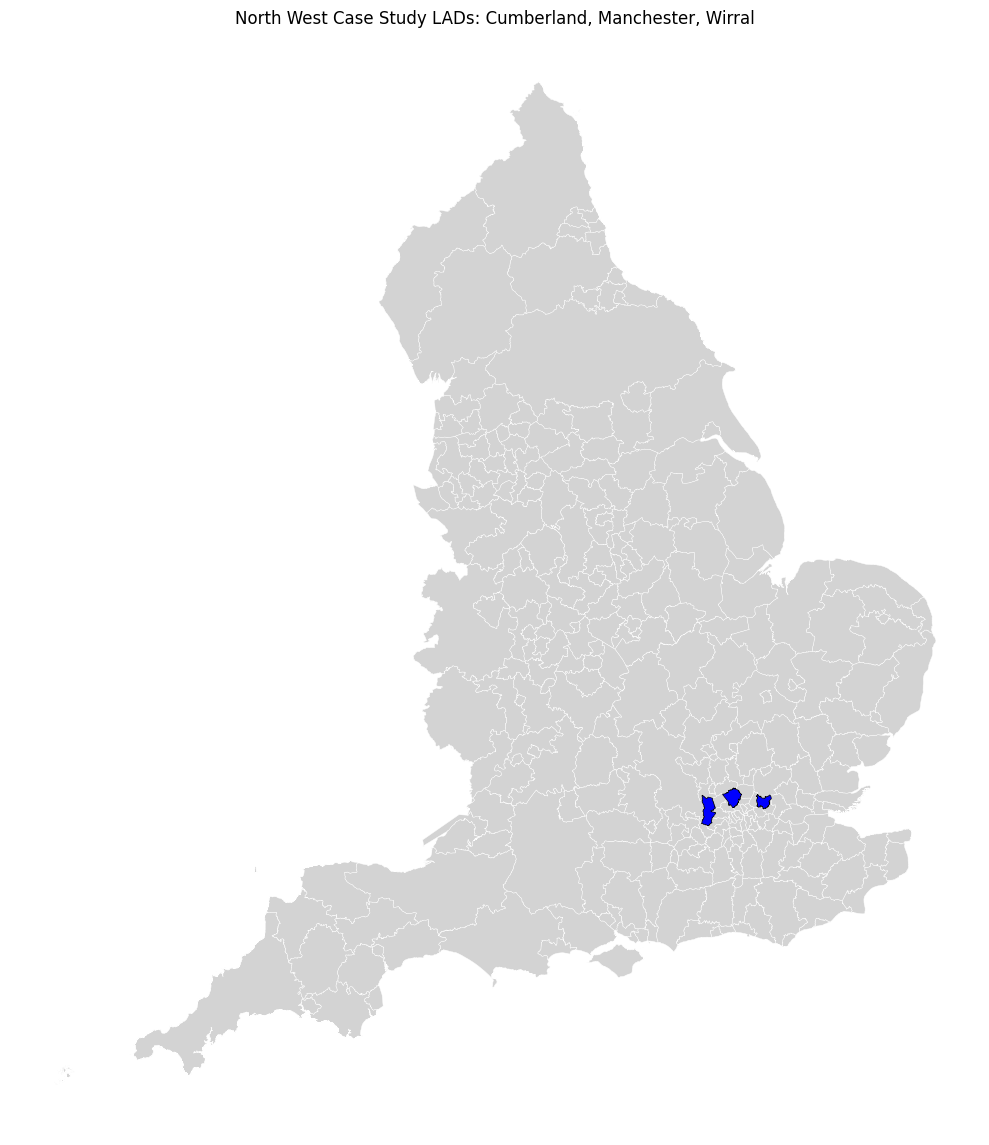

In [39]:
 # plot case study lads
import matplotlib.pyplot as plt

target_lads_nw = ['Barnet', 'Hillingdon', 'Redbridge']

lads_england['highlight'] = lads_england['LAD25NM'].isin(target_lads_nw)

fig, ax = plt.subplots(figsize=(10, 12))
lads_england.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
lads_england[lads_england['highlight']].plot(ax=ax, color='blue', edgecolor='black', linewidth=0.5)

ax.set_title('North West Case Study LADs: Cumberland, Manchester, Wirral')
ax.axis('off')
plt.tight_layout()
plt.show()

In [40]:
# pull schoool level data for london case study MSOAs
target_msoas_london = original_subset_london['MSOA21CD'].unique()

schools_london = schoolData20242025[schoolData20242025['MSOA (code)'].isin(target_msoas_london)]

schools_london = schools_london.merge(
    original_subset_london[['MSOA21CD', 'LAD23NM', 'Dominant', '(High/Low/Non)']],
    left_on='MSOA (code)', right_on='MSOA21CD', how='left'
)

schools_london

,URN,EstablishmentNumber,EstablishmentName,StudentsAchievingGrade5PlusEngMathRate,NumberOfPupils,StudentReceivingFreeSchoolMeals,PercentOfStudentReceivingFreeSchoolMeals,TotalPupils,FemalePupils,PercentFemale,...,LSOA code (2021),IDACI,SAMHI,YPAccessibilityRank,borda_points_total,YPAccessibilityIndex,MSOA21CD,LAD23NM,Dominant,(High/Low/Non)
0,139594.0,4001.0,The Archer Academy,57.1,156,24,15.4,809,413.0,51.05,...,E01000177,8.0,2.0,NaN,NaN,NaN,E02000052,Barnet,Low,"(0%,80%,20%)"
1,136308.0,5406.0,Ashmole Academy,68.8,260,29,11.2,1823,885.0,48.55,...,E01000120,8.0,1.0,435.0,8900.0,3.0,E02000032,Barnet,Low,"(0%,100%,0%)"
2,143082.0,5408.0,Bishop Douglass School Finchley,54.0,124,43,34.7,1013,464.0,45.80,...,E01000179,8.0,2.0,100.0,9627.0,1.0,E02000052,Barnet,Low,"(0%,80%,20%)"
3,137388.0,4211.0,Christ's College Finchley,67.5,157,47,29.9,990,366.0,36.97,...,E01000210,10.0,1.0,212.0,9338.0,2.0,E02000056,Barnet,Low,"(0%,75%,25%)"
4,136418.0,4215.0,The Compton School,51.5,206,68,33.0,1352,619.0,45.78,...,E01000315,3.0,4.0,204.0,9363.0,2.0,E02000045,Barnet,Low,"(0%,80%,20%)"
5,136658.0,4212.0,East Barnet School,57.3,220,40,18.2,1427,632.0,44.29,...,E01000172,9.0,1.0,1138.0,7893.0,6.0,E02000026,Barnet,Low,"(0%,60%,40%)"
6,101362.0,5405.0,Finchley Catholic High School,78.6,173,21,12.1,1192,89.0,7.47,...,E01000284,4.0,2.0,287.0,9196.0,2.0,E02000035,Barnet,Low,"(0%,100%,0%)"
7,101345.0,4003.0,Friern Barnet School,29.6,142,50,35.2,641,316.0,49.30,...,E01000158,5.0,1.0,403.0,8965.0,3.0,E02000038,Barnet,Non,"(20%,0%,80%)"
8,137539.0,5409.0,Hasmonean High School for Boys,73.9,111,13,11.7,772,NaN,NaN,...,E01000198,6.0,3.0,132.0,9554.0,1.0,E02000048,Barnet,Low,"(0%,100%,0%)"
9,137645.0,5400.0,Hendon School,45.2,208,89,42.8,1222,529.0,43.29,...,E01000237,4.0,1.0,85.0,9682.0,1.0,E02000055,Barnet,Non,"(0%,0%,100%)"


In [41]:
# export
schools_london.to_csv("/content/drive/MyDrive/DISSERTATION/DataFiles/FinalDFs/londonSchools.csv", index=False)